# Netflix Data Analysis

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

## Data Loading

In [28]:
df = pd.read_csv('C:/netflix-data-analysis/data/netflix_titles.csv')

## Data Information

In [29]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [31]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [32]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

## Data Cleaning

In [33]:
df = df.drop_duplicates()

df['country'] = df['country'].fillna('Unknown')

df['rating'] = df['rating'].fillna('Not Rated')

df['date_added'] = pd.to_datetime(
    df['date_added'].str.strip(),
    errors='coerce'
)

## Exploratory Data Analysis

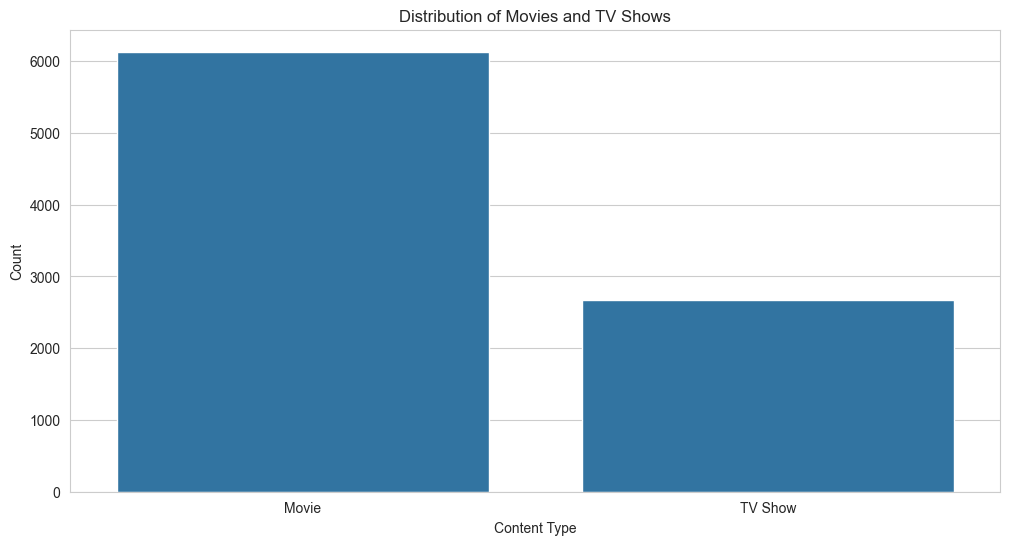

In [34]:
sns.countplot(data=df, x='type')

plt.title('Distribution of Movies and TV Shows')

plt.xlabel('Content Type')

plt.ylabel('Count')

plt.show()

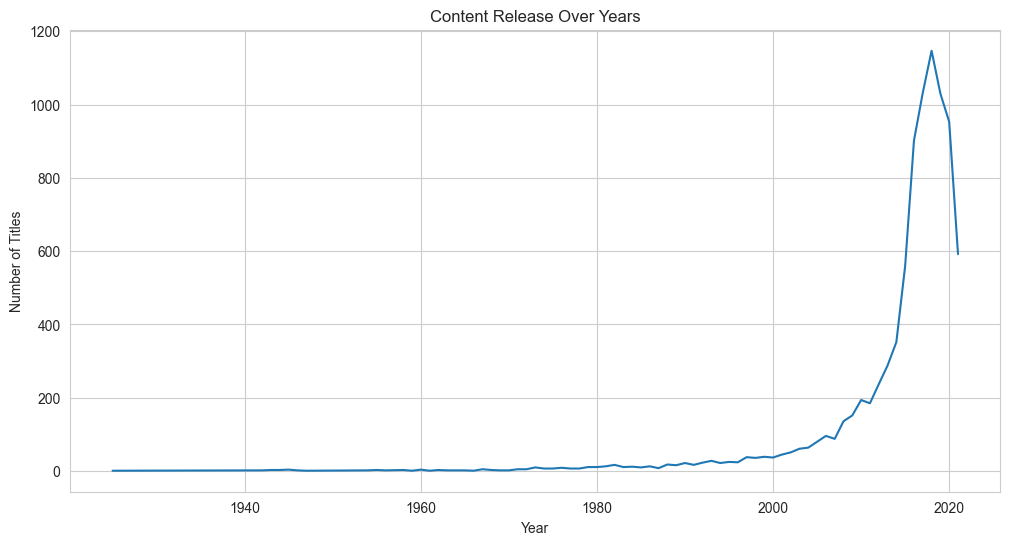

In [35]:
df['release_year'].value_counts().sort_index().plot()

plt.title('Content Release Over Years')

plt.xlabel('Year')

plt.ylabel('Number of Titles')

plt.show()

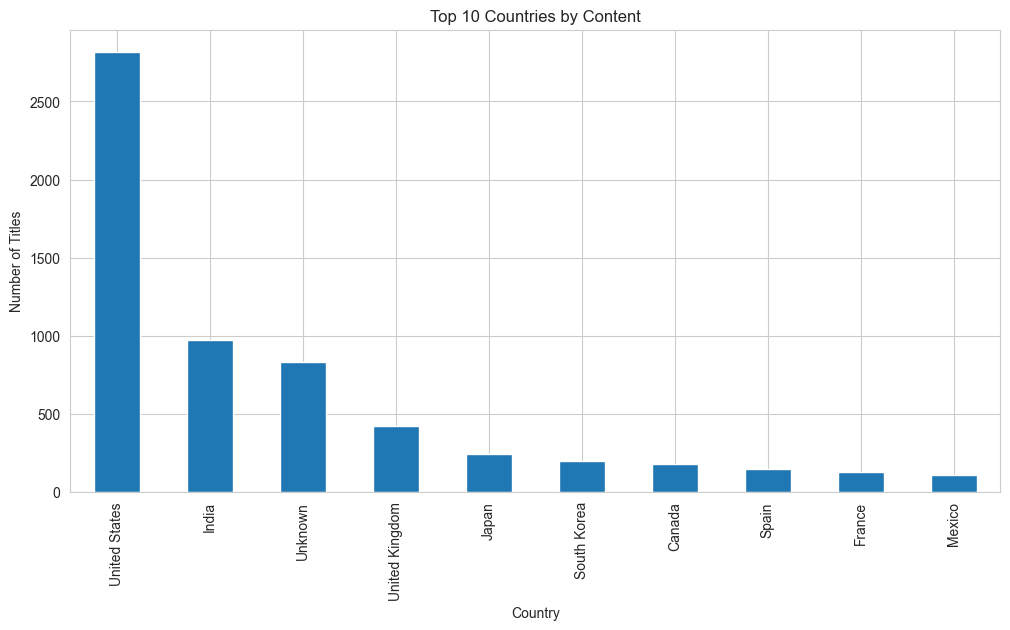

In [36]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')

plt.title('Top 10 Countries by Content')

plt.xlabel('Country')

plt.ylabel('Number of Titles')

plt.show()

In [37]:
plt.savefig('C:/netflix-data-analysis/images/top_countries.png', bbox_inches='tight')                                          #

<Figure size 1200x600 with 0 Axes>

## Insights
### 1. Predominância de filmes no catálogo

A análise mostra que filmes representam a maior parte do catálogo da Netflix. Isso sugere uma estratégia voltada para consumo rápido e ampla variedade de conteúdo cinematográfico.

### 2. Crescimento acelerado do catálogo após 2015

Observa-se um aumento expressivo na quantidade de conteúdos lançados a partir de 2015, indicando a expansão global da plataforma e o aumento de investimentos em produções originais.

### 3. Forte concentração de conteúdo nos Estados Unidos

Os Estados Unidos aparecem como principal produtor de conteúdo presente na plataforma, demonstrando forte influência da indústria audiovisual norte-americana no catálogo da Netflix.

### 4. Conteúdo voltado principalmente para entretenimento popular

Os gêneros mais frequentes estão relacionados a dramas, comédias e produções internacionais, indicando foco em conteúdos de grande alcance e diversidade cultural.

### 5. Predominância de conteúdos para público adulto

Grande parte do catálogo possui classificações voltadas para públicos adultos e adolescentes, sugerindo foco da plataforma em consumidores mais maduros.